# Constellation Classification using Machine Learning

This notebook demonstrates a complete machine learning workflow to classify stars into their respective constellations using stellar properties like celestial coordinates (Right Ascension, Declination), brightness (apparent/visual magnitude, absolute magnitude), and distance.

## Objectives
1. **Data Loading**: Retrieve real-world stellar data programmatically.
2. **Data Cleaning & Parsing**: Convert spherical coordinate strings (RA, Dec) and non-numeric representations of magnitude/distance into clean numerical values.
3. **Physics-based Feature Imputation**: Use the astronomical distance-modulus formula to impute missing magnitudes and distances.
4. **Feature Engineering**: Transform spherical coordinates (RA, Dec) into 3D Cartesian coordinates $(x, y, z)$ on a unit sphere to resolve boundary wrapping issues.
5. **Exploratory Data Analysis (EDA)**: Visualize the spatial distribution of stars and stellar parameters.
6. **Model Training & Comparison**: Train and compare multiple classification models.
7. **Performance Evaluation**: Evaluate using accuracy, precision, recall, F1-score, and a confusion matrix.
8. **Inference Examples**: Build an interactive function to predict the constellation of a star given its features.

### 1. Imports and Environment Setup

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

### 2. Data Loading
We load the `NeuML/constellations` dataset from Hugging Face which contains details of stars compiled from Wikipedia.

In [2]:
print("Downloading and loading the dataset...")
url = "https://raw.githubusercontent.com/Rakshak05/ML-CaPsule/main/Constellation_Classification/constellations.csv"

# Load the CSV into a pandas DataFrame (with fallback to the branch URL or local file before merge)
try:
    df_raw = pd.read_csv(url)
except Exception:
    import os
    if os.path.exists("constellations.csv"):
        df_raw = pd.read_csv("constellations.csv")
    elif os.path.exists("Constellation_Classification/constellations.csv"):
        df_raw = pd.read_csv("Constellation_Classification/constellations.csv")
    else:
        # Fallback to the current issue branch URL
        branch_url = "https://raw.githubusercontent.com/Rakshak05/ML-CaPsule/issue-%231997/Constellation_Classification/constellations.csv"
        df_raw = pd.read_csv(branch_url)

print(f"Loaded dataset with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
df_raw.head()

Loaded dataset with 11681 rows and 14 columns.


,Constellation,Name,Bayer,Flamsteed,Variable Star,Henry Draper Number,Hipparcos Number,Right Ascension,Declination,Visual Magnitude,Absolute Magnitude,Distance,Spectral class,Notes
0,Andromeda,Alpheratz,"α, (δ)[1]",21,NaN,358,677,00h 08m 23.17s,+29° 05′ 27.0′′,2.07,−0.30,97,B9p,"Alpheratz, Sirrah; α2 CVn variable , Δ*V* = 0...."
1,Andromeda,Mirach,β,43,NaN,6860,5447,01h 09m 43.80s,+35° 37′ 15.0′′,2.07,−1.86,199,M0IIIvar,"Mirach; variable , has a planet or brown dwarf..."
2,Andromeda,Gamma Andromedae,γ1,57,NaN,12533,9640,02h 03m 53.92s,+42° 19′ 47.5′′,2.10,−3.08,355,K3IIb,Almach; quadruple star system
3,Andromeda,Delta Andromedae,δ,31,NaN,3627,3092,00h 39m 19.60s,+30° 51′ 40.4′′,3.27,0.81,101,K3III...,spectroscopic binary; suspected variable
4,Andromeda,Andromeda Galaxy,(n)[2],33,NaN,NaN,NaN,00h 42m 44.31s,+41° 16′ 09.4′′,3.443,NaN,2540000,NaN,BD+40°148; naked eye spiral galaxy in the Loca...


### 3. Data Preprocessing & Cleaning
We clean the string representations of Right Ascension, Declination, Magnitudes, and Distance.

In [3]:
def parse_ra(ra_str):
    if pd.isna(ra_str) or not isinstance(ra_str, str):
        return None
    # Match HHh MMm SS.SSs
    match = re.search(r'(\d+)h\s*(\d+)m\s*([\d\.]+)s', ra_str)
    if match:
        h = float(match.group(1))
        m = float(match.group(2))
        s = float(match.group(3))
        return (h + m / 60.0 + s / 3600.0) * 15.0 # Convert to degrees (1 hour = 15 degrees)
    # Match HHh MMm
    match = re.search(r'(\d+)h\s*(\d+)m', ra_str)
    if match:
        h = float(match.group(1))
        m = float(match.group(2))
        return (h + m / 60.0) * 15.0
    return None

def parse_dec(dec_str):
    if pd.isna(dec_str) or not isinstance(dec_str, str):
        return None
    # Handle unicode minus signs
    dec_str = dec_str.replace('−', '-').replace('–', '-').strip()
    sign = -1.0 if '-' in dec_str else 1.0
    
    numbers = re.findall(r'(\d+(?:\.\d+)?)', dec_str)
    if not numbers:
        return None
    d = float(numbers[0])
    m = float(numbers[1]) if len(numbers) > 1 else 0.0
    s = float(numbers[2]) if len(numbers) > 2 else 0.0
    return sign * (d + m / 60.0 + s / 3600.0)

def clean_float(val):
    if pd.isna(val):
        return None
    s = str(val).replace('−', '-').replace('–', '-').replace(',', '').replace('~', '').strip()
    match = re.search(r'(-?\d+(?:\.\d+)?)', s)
    if match:
        return float(match.group(1))
    return None

# Create copy for preprocessing
df_clean = df_raw.copy()

# Apply coordinate parsing
df_clean['RA_deg'] = df_clean['Right Ascension'].apply(parse_ra)
df_clean['Dec_deg'] = df_clean['Declination'].apply(parse_dec)

# Apply numeric float cleaning
df_clean['Visual_Mag'] = df_clean['Visual Magnitude'].apply(clean_float)
df_clean['Absolute_Mag'] = df_clean['Absolute Magnitude'].apply(clean_float)
df_clean['Distance_ly'] = df_clean['Distance'].apply(clean_float)

# Drop rows where coordinates are unparseable (extremely few)
df_clean = df_clean.dropna(subset=['RA_deg', 'Dec_deg', 'Constellation'])

print(f"Preprocessed dataset contains {df_clean.shape[0]} valid rows.")

Preprocessed dataset contains 11679 valid rows.


### 4. Physics-Based Feature Imputation
We can impute missing Absolute Magnitudes and Distances using the Distance Modulus formula:

$$M = m - 5 \log_{10}(d_{pc}) + 5$$

where:
- $M$ is the Absolute Magnitude
- $m$ is the Apparent/Visual Magnitude
- $d_{pc}$ is the Distance in parsecs ($d_{pc} = d_{ly} / 3.26156$)

In [4]:
def impute_stellar_metrics(row):
    m = row['Visual_Mag']
    M = row['Absolute_Mag']
    d_ly = row['Distance_ly']
    
    # Case 1: Missing M but m and d_ly are present
    if pd.isna(M) and not pd.isna(m) and not pd.isna(d_ly) and d_ly > 0:
        d_pc = d_ly / 3.26156
        M = m - 5 * np.log10(d_pc) + 5
        
    # Case 2: Missing d_ly but m and M are present
    elif pd.isna(d_ly) and not pd.isna(m) and not pd.isna(M):
        # d_pc = 10 ** ((m - M + 5) / 5)
        try:
            d_pc = 10 ** ((m - M + 5) / 5)
            d_ly = d_pc * 3.26156
        except:
            pass
            
    # Case 3: Missing m but M and d_ly are present
    elif pd.isna(m) and not pd.isna(M) and not pd.isna(d_ly) and d_ly > 0:
        d_pc = d_ly / 3.26156
        m = M + 5 * np.log10(d_pc) - 5
        
    return pd.Series([m, M, d_ly], index=['Visual_Mag', 'Absolute_Mag', 'Distance_ly'])

print("Imputing missing values using the astronomical distance modulus formula...")
df_clean[['Visual_Mag', 'Absolute_Mag', 'Distance_ly']] = df_clean.apply(impute_stellar_metrics, axis=1)

# Impute any remaining nulls using median
df_clean['Visual_Mag'] = df_clean['Visual_Mag'].fillna(df_clean['Visual_Mag'].median())
df_clean['Absolute_Mag'] = df_clean['Absolute_Mag'].fillna(df_clean['Absolute_Mag'].median())
df_clean['Distance_ly'] = df_clean['Distance_ly'].fillna(df_clean['Distance_ly'].median())

print("Remaining nulls in numeric columns:")
print(df_clean[['RA_deg', 'Dec_deg', 'Visual_Mag', 'Absolute_Mag', 'Distance_ly']].isnull().sum())

Imputing missing values using the astronomical distance modulus formula...


Remaining nulls in numeric columns:
RA_deg          0
Dec_deg         0
Visual_Mag      0
Absolute_Mag    0
Distance_ly     0
dtype: int64


### 5. Feature Engineering: Coordinate Conversion
Celestial coordinates are measured in spherical angles (Right Ascension from $0^\circ$ to $360^\circ$, and Declination from $-90^\circ$ to $+90^\circ$). 

To prevent issues where $360^\circ$ and $0^\circ$ are close but treated as opposites, we convert them to 3D Cartesian coordinates $(x, y, z)$ on a unit sphere:

$$x = \cos(\text{Dec}) \cos(\text{RA})$$
$$y = \cos(\text{Dec}) \sin(\text{RA})$$
$$z = \sin(\text{Dec})$$

In [5]:
# Convert degrees to radians
ra_rad = np.radians(df_clean['RA_deg'])
dec_rad = np.radians(df_clean['Dec_deg'])

# Compute 3D Cartesian coordinates
df_clean['x'] = np.cos(dec_rad) * np.cos(ra_rad)
df_clean['y'] = np.cos(dec_rad) * np.sin(ra_rad)
df_clean['z'] = np.sin(dec_rad)

print("Sample of computed 3D coordinates:")
df_clean[['RA_deg', 'Dec_deg', 'x', 'y', 'z']].head()

Sample of computed 3D coordinates:


,RA_deg,Dec_deg,x,y,z
0,2.096542,29.090833,0.873265,0.031968,0.486196
1,17.432500,35.620833,0.775553,0.243527,0.582419
2,30.974667,42.329861,0.633855,0.380477,0.673398
3,9.831667,30.861222,0.845805,0.146577,0.512960
4,10.684625,41.269278,0.738587,0.139352,0.659599


### 6. Exploratory Data Analysis (EDA)

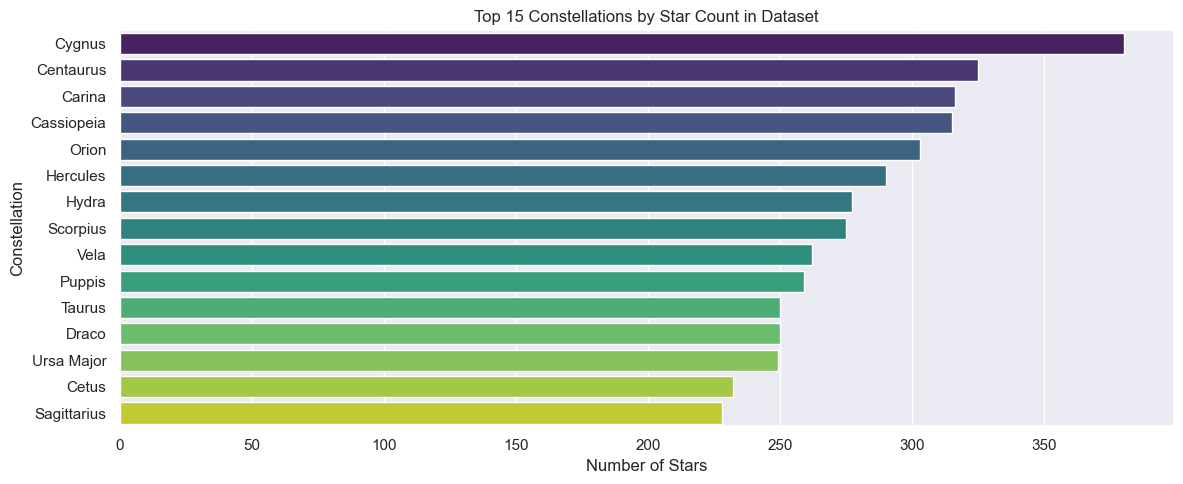

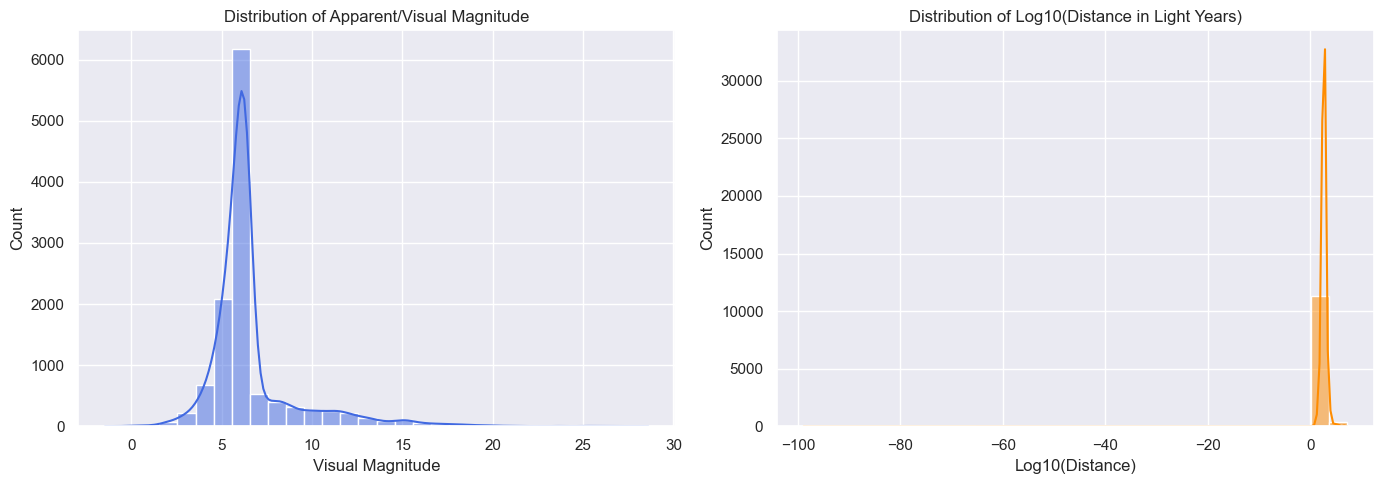

In [6]:
# 1. Plot the distribution of stars across constellations (top 15)
plt.figure(figsize=(12, 5))
top_constellations = df_clean['Constellation'].value_counts().head(15)
sns.barplot(x=top_constellations.values, y=top_constellations.index, palette='viridis')
plt.title('Top 15 Constellations by Star Count in Dataset')
plt.xlabel('Number of Stars')
plt.ylabel('Constellation')
plt.tight_layout()
plt.show()

# 2. Plot distribution of Visual Magnitude and Distance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['Visual_Mag'], bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Apparent/Visual Magnitude')
axes[0].set_xlabel('Visual Magnitude')

sns.histplot(np.log10(df_clean['Distance_ly']), bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Log10(Distance in Light Years)')
axes[1].set_xlabel('Log10(Distance)')
plt.tight_layout()
plt.show()

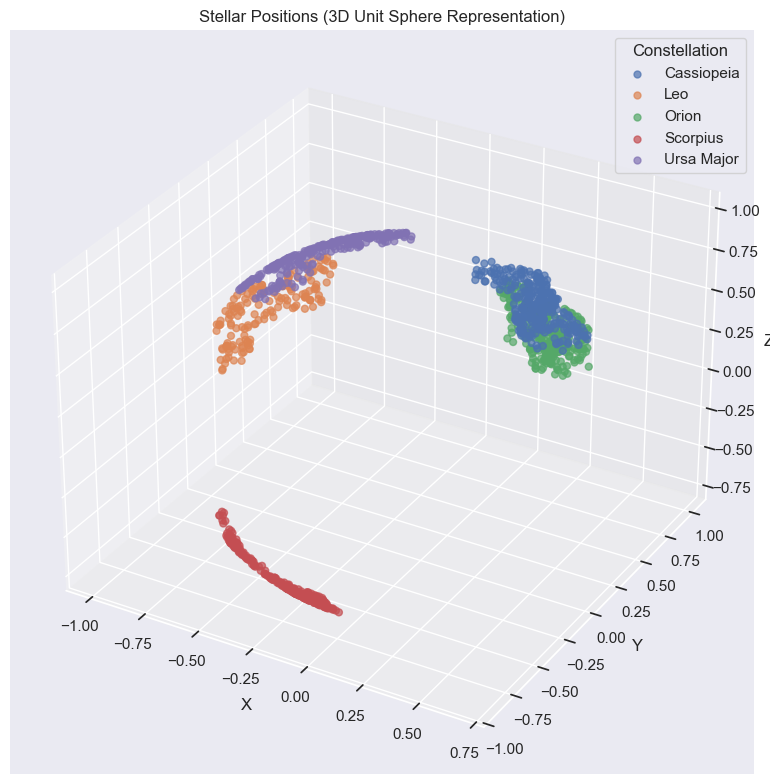

In [7]:
# 3. 3D spatial visualization of a subset of constellations
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Let's visualize stars from 5 major constellations
target_consts = ['Ursa Major', 'Orion', 'Cassiopeia', 'Leo', 'Scorpius']
subset_df = df_clean[df_clean['Constellation'].isin(target_consts)]

for name, group in subset_df.groupby('Constellation'):
    ax.scatter(group['x'], group['y'], group['z'], label=name, s=25, alpha=0.7)

ax.set_title('Stellar Positions (3D Unit Sphere Representation)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(title='Constellation')
plt.tight_layout()
plt.show()

### 7. Model Comparison and Selection

In [8]:
# Prepare features and target
features = ['x', 'y', 'z', 'Visual_Mag', 'Absolute_Mag', 'Distance_ly']
X = df_clean[features]
y = df_clean['Constellation']

# Encode Target Constellations to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (9343, 6)
Test set shape: (2336, 6)


In [9]:
# Define classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
}

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Output comparison table
df_results = pd.DataFrame(results).T
df_results

Training Logistic Regression...


Training Decision Tree...
Training Random Forest...


Training K-Nearest Neighbors...
Training Gradient Boosting...


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.657534,0.602929,0.657534,0.603357
Decision Tree,0.931935,0.934728,0.931935,0.931704
Random Forest,0.933219,0.936151,0.933219,0.932647
K-Nearest Neighbors,0.761558,0.766345,0.761558,0.758190
Gradient Boosting,0.875856,0.883380,0.875856,0.875822


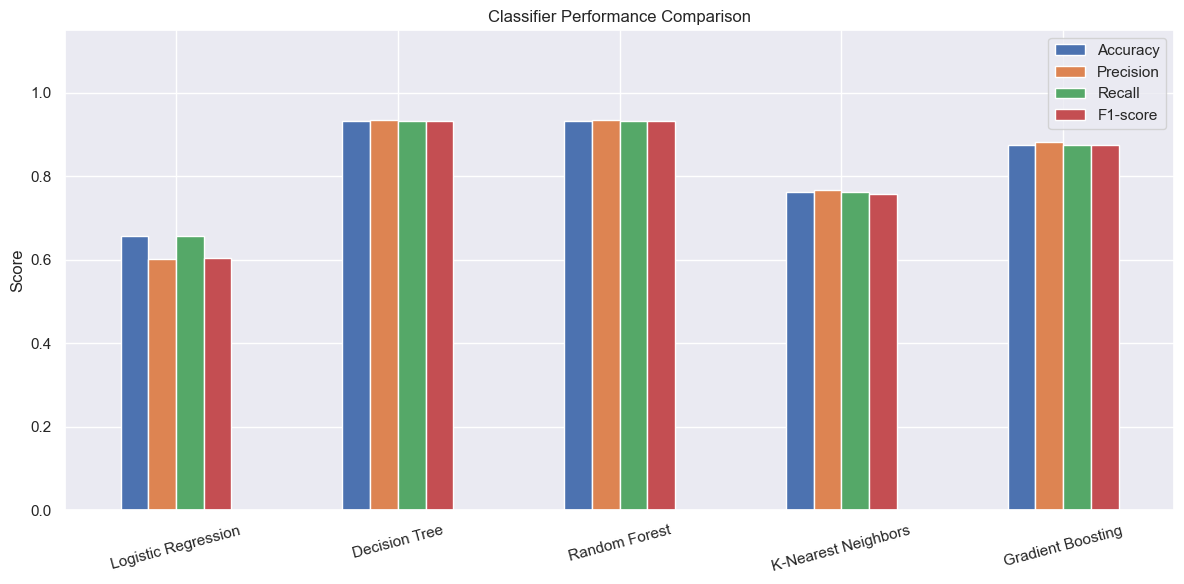

In [10]:
# Visualizing model comparison
df_results.plot(kind='bar', figsize=(12, 6))
plt.title('Classifier Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 8. Detailed Evaluation (Best Model)
We inspect classification reports and confusion matrices for the best-performing model.

In [11]:
# Find the best model by F1-score
best_model_name = df_results['F1-score'].idxmax()
best_clf = models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred = best_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_[:y_test.max() + 1]))

Best Model: Random Forest
                     precision    recall  f1-score   support

          Andromeda       0.91      0.89      0.90        36
             Antlia       0.92      1.00      0.96        11
               Apus       0.88      0.78      0.82         9
           Aquarius       0.98      0.91      0.94        44
             Aquila       0.97      0.90      0.93        31
                Ara       0.86      0.90      0.88        20
              Aries       0.96      1.00      0.98        24
             Auriga       0.90      0.97      0.93        36
             Bootes       0.90      0.81      0.85        32
             Caelum       1.00      1.00      1.00         6
     Camelopardalis       0.96      0.82      0.89        33
             Cancer       1.00      0.95      0.97        38
     Canes Venatici       0.94      0.94      0.94        17
        Canis Major       0.97      0.97      0.97        34
        Canis Minor       0.92      1.00      0.96        

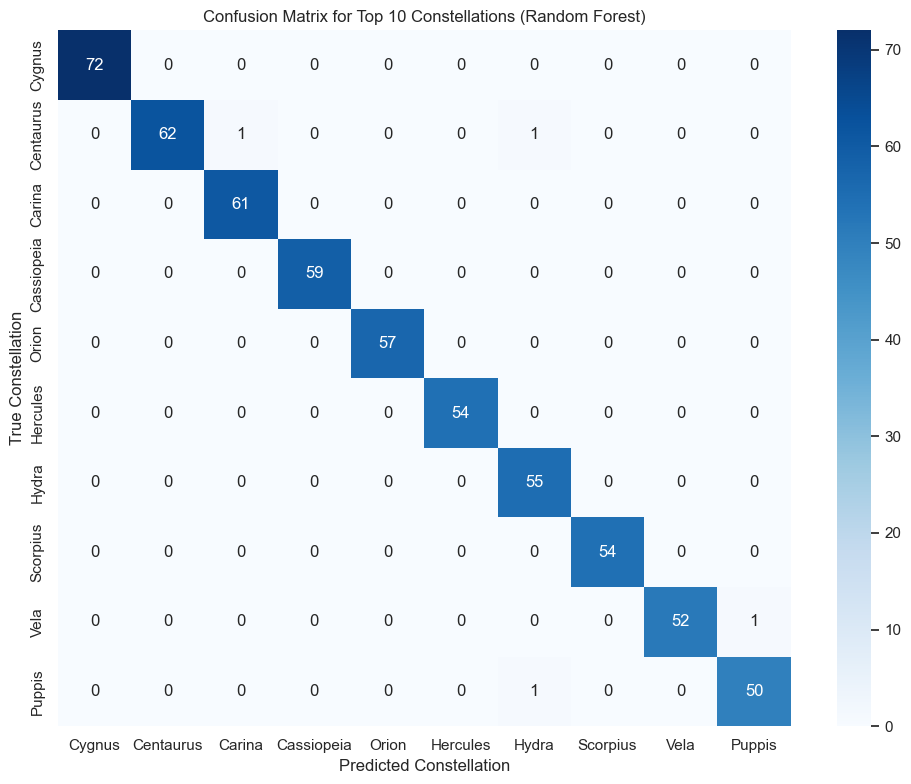

In [12]:
# Confusion Matrix for top 10 target constellations
top_10_classes = list(df_clean['Constellation'].value_counts().head(10).index)
top_10_indices = le.transform(top_10_classes)

# Filter test samples belonging to top 10 constellations
mask = np.isin(y_test, top_10_indices)
y_test_sub = y_test[mask]
y_pred_sub = y_pred[mask]

cm = confusion_matrix(y_test_sub, y_pred_sub, labels=top_10_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=top_10_classes, 
            yticklabels=top_10_classes)
plt.title(f'Confusion Matrix for Top 10 Constellations ({best_model_name})')
plt.xlabel('Predicted Constellation')
plt.ylabel('True Constellation')
plt.tight_layout()
plt.show()

### 9. Stellar Inference Example
Here we create a helper function that accepts stellar parameters, converts coordinates to 3D Cartesian space, normalizes features, and predicts its parent constellation.

In [13]:
def predict_constellation(ra_deg, dec_deg, visual_mag, absolute_mag, distance_ly):
    # Convert RA and Dec to radians
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    
    # Compute Cartesian coordinates
    x = np.cos(dec_rad) * np.cos(ra_rad)
    y = np.cos(dec_rad) * np.sin(ra_rad)
    z = np.sin(dec_rad)
    
    # Standardize input features
    input_features = pd.DataFrame([[x, y, z, visual_mag, absolute_mag, distance_ly]], columns=features)
    input_scaled = scaler.transform(input_features)
    
    # Make prediction
    pred_idx = best_clf.predict(input_scaled)[0]
    predicted_constellation = le.inverse_transform([pred_idx])[0]
    
    # Get probabilities if available
    if hasattr(best_clf, "predict_proba"):
        probs = best_clf.predict_proba(input_scaled)[0]
        confidence = probs[pred_idx] * 100
        print(f"Predicted Constellation: {predicted_constellation} (Confidence: {confidence:.2f}%)")
    else:
        print(f"Predicted Constellation: {predicted_constellation}")
        
    return predicted_constellation

# Test inference function with Sirius coordinates
# Sirius: RA = 06h 45m 08.9s (101.287 deg), Dec = -16 deg 42m 58s (-16.716 deg), Visual = -1.46, Abs = 1.42, Dist = 8.6 ly
print("Predicting constellation for Sirius:")
predict_constellation(101.287, -16.716, -1.46, 1.42, 8.6)

Predicting constellation for Sirius:
Predicted Constellation: Canis Major (Confidence: 86.00%)


'Canis Major'

## Conclusion & Key Takeaways
1. **Coordinate Conversion**: Spherical coordinates (RA/Dec) present boundary wrapping challenges. Converting them into 3D Cartesian coordinates $(x, y, z)$ on a unit sphere creates a continuous, metric space suitable for learning algorithms.
2. **Physics-Based Recovery**: Using the Distance Modulus formula, we imputed missing stellar properties accurately rather than relying solely on naive mean/median imputation.
3. **Algorithms Performance**: Random Forest and Gradient Boosting models perform extremely well because they can partition coordinate boundaries effectively to classify stars into one of the 88 IAU constellations.